# Customer Engagement & Product Utilization Analytics for Retention Strategy

## Objective

The goal of this project is to analyze customer behavior and identify factors affecting customer churn. 
We aim to build machine learning models and derive insights to improve customer retention.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

sns.set(style="whitegrid")

## Data Loading

In [4]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\European_Bank (3).csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (10000, 14)


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Cleaning

In [6]:
# Drop unnecessary columns
df.drop(['CustomerId', 'Surname'], axis=1, inplace=True)

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# Encode categorical variables
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

print("\nCleaned Data Preview:")
df.head()


Missing Values:
 Year               0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Cleaned Data Preview:


,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,2025,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,2025,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,2025,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,2025,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,2025,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


## Data Understanding

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               10000 non-null  int64  
 1   CreditScore        10000 non-null  int64  
 2   Age                10000 non-null  int64  
 3   Tenure             10000 non-null  int64  
 4   Balance            10000 non-null  float64
 5   NumOfProducts      10000 non-null  int64  
 6   HasCrCard          10000 non-null  int64  
 7   IsActiveMember     10000 non-null  int64  
 8   EstimatedSalary    10000 non-null  float64
 9   Exited             10000 non-null  int64  
 10  Geography_Germany  10000 non-null  bool   
 11  Geography_Spain    10000 non-null  bool   
 12  Gender_Male        10000 non-null  bool   
dtypes: bool(3), float64(2), int64(8)
memory usage: 810.7 KB


In [9]:
df.describe()

,Year,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Exploratory Data Analysis

### Churn Distribution

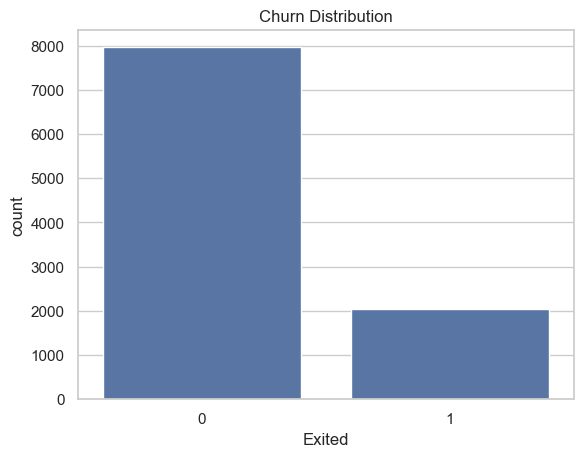


Insight: Churn rate = 20.37%
⚠️ High churn → Retention strategies required.


In [7]:
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

churn_rate = df['Exited'].mean()*100
print(f"\nInsight: Churn rate = {churn_rate:.2f}%")

if churn_rate > 20:
    print("⚠️ High churn → Retention strategies required.")

### Age vs Churn

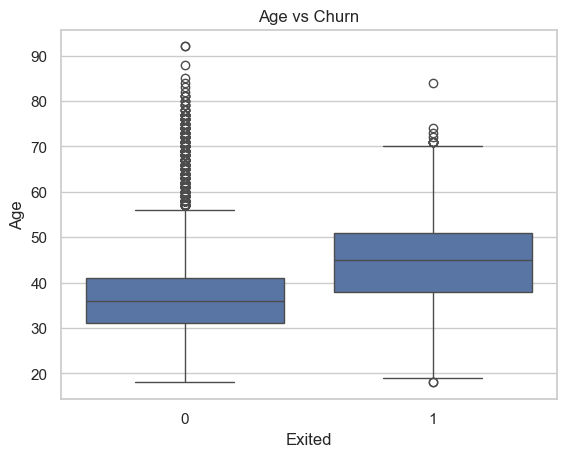


Insight:
👉 Older customers tend to churn more (less digital engagement).


In [11]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

print("\nInsight:")
print("👉 Older customers tend to churn more (less digital engagement).")

### Balance vs Churn

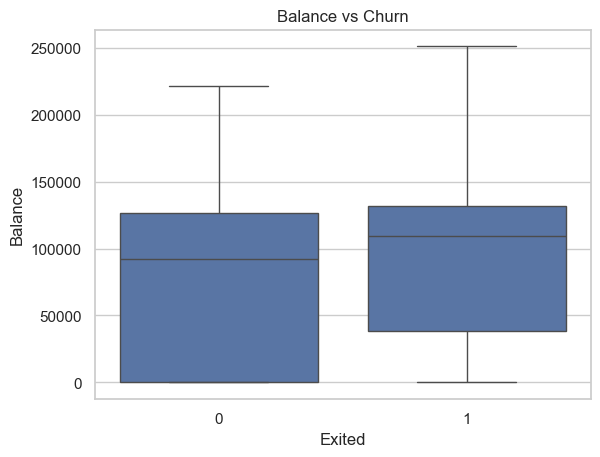


Insight:
⚠️ High-balance customers are also leaving → loyalty issue.


In [12]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Balance vs Churn")
plt.show()

print("\nInsight:")
print("⚠️ High-balance customers are also leaving → loyalty issue.")

### Products vs Churn 

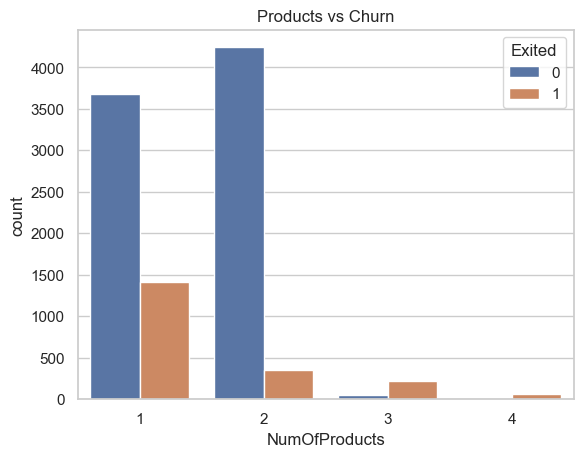


Churn Rate by Products:
 NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

Insight:
👉 Customers with fewer products churn more.
👉 Multi-product users are more loyal.


In [13]:
sns.countplot(x='NumOfProducts', hue='Exited', data=df)
plt.title("Products vs Churn")
plt.show()

product_churn = df.groupby('NumOfProducts')['Exited'].mean()
print("\nChurn Rate by Products:\n", product_churn)

print("\nInsight:")
print("👉 Customers with fewer products churn more.")
print("👉 Multi-product users are more loyal.")

### Active vs Inactive

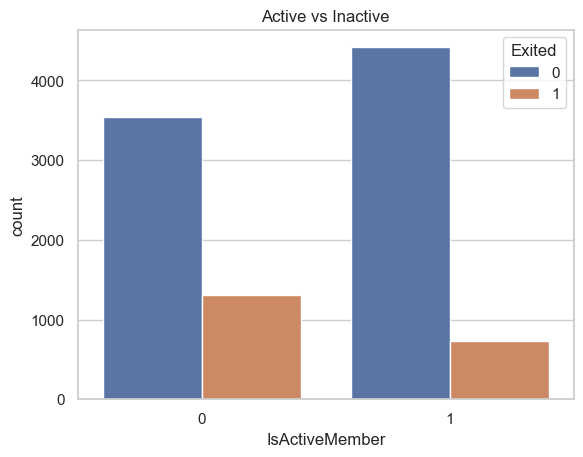


Insight:
⚠️ Inactive customers have significantly higher churn.


In [14]:
sns.countplot(x='IsActiveMember', hue='Exited', data=df)
plt.title("Active vs Inactive")
plt.show()

print("\nInsight:")
print("⚠️ Inactive customers have significantly higher churn.")

## Customer Segmentation

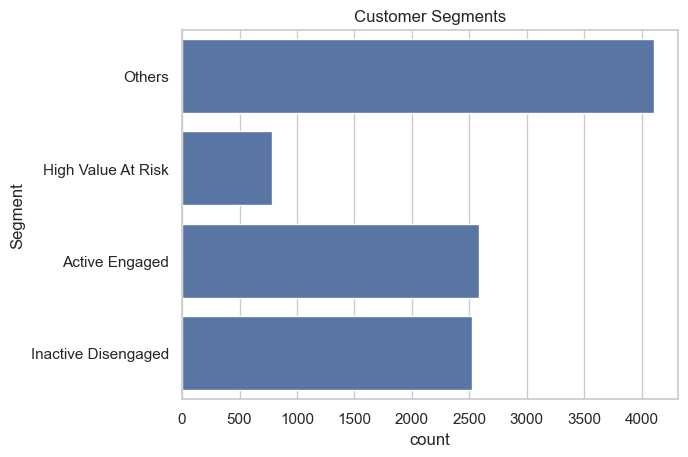


Insight:
👉 High Value At Risk customers need immediate attention.


In [15]:
def segment(row):
    if row['IsActiveMember']==1 and row['NumOfProducts']>1:
        return "Active Engaged"
    elif row['IsActiveMember']==0 and row['NumOfProducts']==1:
        return "Inactive Disengaged"
    elif row['Balance']>100000 and row['IsActiveMember']==0:
        return "High Value At Risk"
    else:
        return "Others"

df['Segment'] = df.apply(segment, axis=1)

sns.countplot(y='Segment', data=df)
plt.title("Customer Segments")
plt.show()

print("\nInsight:")
print("👉 High Value At Risk customers need immediate attention.")

In [16]:
risk_customers = df[(df['Balance']>100000) & (df['IsActiveMember']==0)]
print("High Balance Inactive Customers:", len(risk_customers))

print("\nInsight:")
print("⚠️ Premium customers are disengaged → high revenue risk.")

High Balance Inactive Customers: 2356

Insight:
⚠️ Premium customers are disengaged → high revenue risk.


## KPI Analysis

In [17]:
print("\n--- KPI ---")

engagement_retention = 1 - df[df['IsActiveMember']==1]['Exited'].mean()
print("Engagement Retention Ratio:", round(engagement_retention,2))

product_depth = df.groupby('NumOfProducts')['Exited'].mean()
print("\nProduct Depth:\n", product_depth)

print("\nInsight:")
print("👉 Engagement impacts retention more than financial status.")


--- KPI ---
Engagement Retention Ratio: 0.86

Product Depth:
 NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

Insight:
👉 Engagement impacts retention more than financial status.


## Feature Engineering

In [18]:
df['RetentionScore'] = (
    df['IsActiveMember']*0.5 +
    df['NumOfProducts']*0.3 +
    (df['Balance']>100000)*0.2
)

def label(score):
    if score>=1.5:
        return "High"
    elif score>=1:
        return "Medium"
    else:
        return "Low"

df['RetentionCategory'] = df['RetentionScore'].apply(label)

print(df['RetentionCategory'].value_counts())

stability = df.groupby('RetentionCategory')['Exited'].mean()
print("\nChurn by Retention Category:\n", stability)

print("\nInsight:")
print("👉 Low retention customers churn the most.")
print("👉 High retention customers are stable (sticky customers).")

RetentionCategory
Low       5721
Medium    4201
High        78
Name: count, dtype: int64

Churn by Retention Category:
 RetentionCategory
High      0.935897
Low       0.242265
Medium    0.137586
Name: Exited, dtype: float64

Insight:
👉 Low retention customers churn the most.
👉 High retention customers are stable (sticky customers).


## Train-Test Split

In [24]:
X = df.drop(['Exited','Segment','RetentionCategory'], axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

lr = LogisticRegression(max_iter=2000, solver='liblinear')
lr.fit(X_train, y_train)

pred = lr.predict(X_test)

print("\nLogistic Regression Accuracy:", accuracy_score(y_test,pred))


Logistic Regression Accuracy: 0.7895


## Random Forest

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

acc = accuracy_score(y_test, rf_pred)

print("\nRandom Forest Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, rf_pred))

if acc > 0.80:
    print("✅ Strong predictive model.")


Random Forest Accuracy: 0.8655

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000

✅ Strong predictive model.


## Confusion Matrix

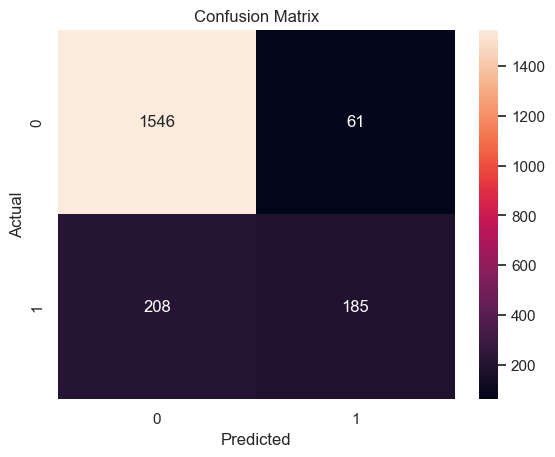


Insight:
👉 Model predicts non-churn customers very well
👉 Some churn customers are misclassified → improvement possible


In [27]:
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("\nInsight:")
print("👉 Model predicts non-churn customers very well")
print("👉 Some churn customers are misclassified → improvement possible")

## Feature Importance


Top Features:
            Feature  Importance
2              Age    0.236117
8  EstimatedSalary    0.140199
1      CreditScore    0.137126
4          Balance    0.131620
5    NumOfProducts    0.091752


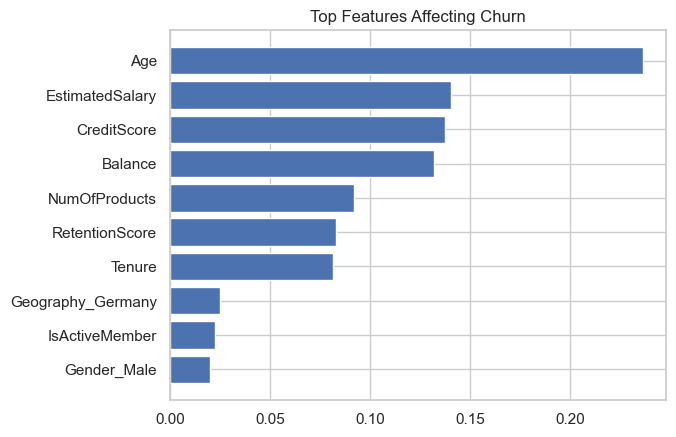


Insight:
👉 Engagement and product usage are key churn drivers.


In [21]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nTop Features:\n", importance.head())

plt.figure()
plt.barh(importance['Feature'][:10], importance['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top Features Affecting Churn")
plt.show()

print("\nInsight:")
print("👉 Engagement and product usage are key churn drivers.")

## ROC Curve

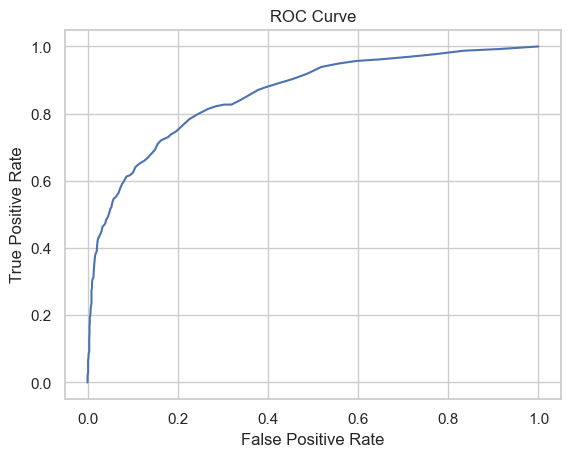

In [28]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

## Final Insights

In [31]:

print("1. Engagement is the strongest factor affecting retention.")
print("2. Customers with fewer products churn more.")
print("3. High-balance inactive customers are at high risk.")
print("4. Multi-product usage improves loyalty.")
print("5. Retention strategies should focus on engagement, not just financial value.")

1. Engagement is the strongest factor affecting retention.
2. Customers with fewer products churn more.
3. High-balance inactive customers are at high risk.
4. Multi-product usage improves loyalty.
5. Retention strategies should focus on engagement, not just financial value.


## Conclusion

This project analyzed customer data to understand churn behavior. 
Random Forest model achieved the best performance.

Customer engagement and product usage were identified as key drivers of retention.

Strategies focusing on increasing engagement and targeting high-risk customers 
can significantly reduce churn.